# 🧹 Notebook 03: Data Cleaning + NLP Sentiment Analysis
## AI Tool Discovery Engine — PGD Data Science Final Project

---

### 🗺️ What This Notebook Does

| Step | What We're Doing | Why It Matters |
|------|-----------------|----------------|
| **1. Load Data** | Read both CSV files into Python | Everything starts here |
| **2. Explore** | Understand shape, missing values, distributions | Know your data before touching it |
| **3. Clean Metadata** | Fix missing values, standardise types | Garbage in = garbage out |
| **4. Clean Reviews** | Remove noise from review text | Better text = better NLP |
| **5. NLP Preprocessing** | Tokenise, remove stopwords, lemmatise | Prepare text for the model |
| **6. VADER Sentiment** | Score every review −1 to +1 | The heart of our engine |
| **7. Aggregate** | Sentiment score per tool | What we feed the hybrid engine |
| **8. Visualise** | Charts to understand and defend your work | Essential for your report |
| **9. Save** | Export clean data to `/data/processed/` | Ready for Milestone 5 |

---

> 💡 **Plain English Reminder:** Think of this notebook as a car wash + quality inspection for your data.
> We clean it, inspect it, and stamp it as road-ready for the engines we'll build next.

---
## 📦 Step 0: Install & Import Libraries

**What we need and why:**
- `pandas` — our data table tool (like Excel in Python)
- `numpy` — number crunching
- `nltk` — Natural Language Toolkit (gives us VADER + text tools)
- `re` — built-in Python tool to clean text with patterns
- `matplotlib` / `seaborn` — for drawing charts
- `tqdm` — shows a progress bar (useful with 76,000 reviews!)

In [1]:
# Run this cell ONCE to install everything you need
# If you're on Anaconda, most of these are already installed
!pip install nltk textblob tqdm seaborn pandas numpy matplotlib --quiet

In [2]:
# ── Standard libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

# ── NLP libraries ────────────────────────────────────────────────
import nltk

# Download required NLTK data packs (only needed the first time)
nltk.download('vader_lexicon', quiet=True)   # The VADER sentiment model
nltk.download('stopwords', quiet=True)        # Common words to ignore (the, is, a...)
nltk.download('punkt', quiet=True)            # Sentence/word splitter
nltk.download('wordnet', quiet=True)          # Word meaning database (for lemmatisation)
nltk.download('punkt_tab', quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ── Visualisation ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Progress bar ─────────────────────────────────────────────────
from tqdm import tqdm
tqdm.pandas()   # Lets us use progress_apply() on dataframes

# ── Set chart style ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 📁 Step 1: Set File Paths & Load Data

**Important:** Make sure your two CSV files are in the same folder as this notebook,
OR update the paths below to point to where you saved them.

In [3]:
# ── File paths — update these if your files are in a different folder ──
METADATA_PATH = 'ai_tools_metadata.csv'
REVIEWS_PATH  = 'ai_tools_reviews.csv'

# ── Output folder — we'll save cleaned data here ──────────────────
OUTPUT_DIR = 'data/processed/'
os.makedirs(OUTPUT_DIR, exist_ok=True)   # Creates the folder if it doesn't exist

# ── Load the data ──────────────────────────────────────────────────
print('Loading data files...')

meta_df    = pd.read_csv(METADATA_PATH, encoding='utf-8-sig')   # utf-8-sig handles the BOM character
reviews_df = pd.read_csv(REVIEWS_PATH,  encoding='utf-8-sig')

print(f'\n✅ Metadata loaded:  {meta_df.shape[0]:,} tools  ×  {meta_df.shape[1]} columns')
print(f'✅ Reviews loaded:   {reviews_df.shape[0]:,} reviews  ×  {reviews_df.shape[1]} columns')

Loading data files...

✅ Metadata loaded:  482 tools  ×  30 columns
✅ Reviews loaded:   69,727 reviews  ×  13 columns


---
## 🔍 Step 2: Explore the Data

Before cleaning anything, we look at what we have.
This is like surveying a messy room before deciding how to tidy it.

In [4]:
# ── Metadata: first look ───────────────────────────────────────────
print('═' * 60)
print('METADATA — First 3 rows')
print('═' * 60)
meta_df.head(3)

════════════════════════════════════════════════════════════
METADATA — First 3 rows
════════════════════════════════════════════════════════════


,app_id,app_name,developer,category_scraped,project_category,avg_rating,total_ratings,total_reviews,installs,description,...,free,url,icon_url,genre_id,ratings_1_star,ratings_2_star,ratings_3_star,ratings_4_star,ratings_5_star,scraped_at
0,ai.chat.gpt.bot,ChatOn - AI Chat Bot Assistant,AIBY Inc.,Productivity,Generative Text / Chatbots,4.530914,415843,4815,28956985,Welcome to the world of AI assistance! Meet Ch...,...,True,https://play.google.com/store/apps/details?id=...,https://play-lh.googleusercontent.com/p8Q9Nc4A...,PRODUCTIVITY,24512,6145,19548,39404,326193,2026-02-21T09:26:23.205626
1,com.scaleup.chatai,AI Chatbot - Nova,ScaleUp,Productivity,Generative Text / Chatbots,3.817843,2099272,24702,88953865,Nova is a revolutionary AI chatbot and persona...,...,True,https://play.google.com/store/apps/details?id=...,https://play-lh.googleusercontent.com/xDCktRsb...,PRODUCTIVITY,472745,63909,110348,178184,1274041,2026-02-21T09:26:26.039446
2,com.codespaceapps.aichat,Chatbot AI - Search Assistant,Codespace Dijital,Productivity,Generative Text / Chatbots,4.386683,853354,3558,43643439,Welcome to the world of AI assistance! Meet Ch...,...,True,https://play.google.com/store/apps/details?id=...,https://play-lh.googleusercontent.com/oG6s8oEa...,PRODUCTIVITY,76628,17701,38039,87567,633364,2026-02-21T09:26:28.472949


In [5]:
# ── Column types and missing value counts ─────────────────────────
print('METADATA — Column info & missing values')
print('─' * 50)
missing = meta_df.isnull().sum()
missing_pct = (missing / len(meta_df) * 100).round(1)
info_df = pd.DataFrame({'dtype': meta_df.dtypes, 'missing': missing, 'missing_%': missing_pct})
info_df[info_df['missing'] > 0].sort_values('missing_%', ascending=False)

METADATA — Column info & missing values
──────────────────────────────────────────────────


,dtype,missing,missing_%
android_version,float64,482,100.0
size,float64,482,100.0
updated_on,float64,34,7.1
released_on,object,3,0.6


In [6]:
# ── Reviews: first look ────────────────────────────────────────────
print('═' * 60)
print('REVIEWS — First 3 rows')
print('═' * 60)
reviews_df.head(3)

════════════════════════════════════════════════════════════
REVIEWS — First 3 rows
════════════════════════════════════════════════════════════


,app_id,review_id,user_name,review_text,review_title,star_rating,thumbs_up_count,review_date,reply_text,reply_date,app_version_review,sort_source,scraped_at
0,ai.chat.gpt.bot,67119987-51f4-44b1-bc96-65d9ac7b74f9,Leafand Lotus,"Weak. Can't upload images for reference, the a...",NaN,1,5,2026-02-03 20:36:24,Hello! Thank you for your feedback. We'd appre...,2026-02-09 16:42:08,NaN,relevant,2026-02-21T09:50:35.531042
1,ai.chat.gpt.bot,39f0ae17-5bb6-462c-976c-497a468e6d71,Hayden Winn,It has lower models and only allows 5 free pro...,NaN,1,7,2026-01-08 03:40:33,NaN,NaN,NaN,relevant,2026-02-21T09:50:35.531081
2,ai.chat.gpt.bot,28426411-3f9f-4d26-b4eb-14fb027297e9,Jenn,it's a little tricky sometimes to get the righ...,NaN,5,922,2024-09-09 23:16:54,NaN,NaN,1.49.432-480,relevant,2026-02-21T09:50:35.531093


In [7]:
# ── Reviews missing values ─────────────────────────────────────────
print('REVIEWS — Missing values')
rev_missing = reviews_df.isnull().sum()
rev_missing_pct = (rev_missing / len(reviews_df) * 100).round(1)
rev_info = pd.DataFrame({'missing': rev_missing, 'missing_%': rev_missing_pct})
rev_info[rev_info['missing'] > 0].sort_values('missing_%', ascending=False)

REVIEWS — Missing values


,missing,missing_%
review_title,69727,100.0
reply_text,48355,69.3
reply_date,48355,69.3
app_version_review,9867,14.2
user_name,2,0.0
review_text,1,0.0


In [8]:
# ── Key stats summary ──────────────────────────────────────────────
print('╔══════════════════════════════════════════╗')
print('║         DATASET QUICK FACTS              ║')
print('╠══════════════════════════════════════════╣')
print(f'║  Total AI tools (apps):   {meta_df["app_id"].nunique():>6,}          ║')
print(f'║  Total reviews:           {len(reviews_df):>6,}          ║')
print(f'║  Unique reviewers:        {reviews_df["user_name"].nunique():>6,}          ║')
print(f'║  Apps with reviews:       {reviews_df["app_id"].nunique():>6,}          ║')
print(f'║  Avg reviews per app:     {len(reviews_df)/reviews_df["app_id"].nunique():>6.0f}          ║')
print(f'║  Star rating range:   {reviews_df["star_rating"].min()} – {reviews_df["star_rating"].max()}               ║')
print('╚══════════════════════════════════════════╝')

╔══════════════════════════════════════════╗
║         DATASET QUICK FACTS              ║
╠══════════════════════════════════════════╣
║  Total AI tools (apps):      482          ║
║  Total reviews:           69,727          ║
║  Unique reviewers:        64,416          ║
║  Apps with reviews:          482          ║
║  Avg reviews per app:        145          ║
║  Star rating range:   1 – 5               ║
╚══════════════════════════════════════════╝


---
## 🧹 Step 3: Clean the Metadata

We'll fix:
- **Missing numeric values** → fill with sensible defaults or drop
- **Date columns** → convert to proper datetime format
- **Redundant columns** → drop columns we don't need
- **Column types** → make sure numbers are numbers, not text

In [9]:
# ── Work on a copy — never modify the original ─────────────────────
meta = meta_df.copy()

# ── 1. Drop columns we don't need for modelling ────────────────────
#    These are URLs and app-store metadata not relevant to recommendations
cols_to_drop = ['url', 'icon_url', 'android_version', 'app_version',
                'content_rating', 'genre_id', 'offers_iap', 'scraped_at']
meta.drop(columns=[c for c in cols_to_drop if c in meta.columns], inplace=True)
print(f'Dropped {len(cols_to_drop)} non-essential columns')

# ── 2. Fix date columns ────────────────────────────────────────────
meta['released_on'] = pd.to_datetime(meta['released_on'], errors='coerce')
# updated_on is stored as a float timestamp — convert to datetime
meta['updated_on'] = pd.to_datetime(meta['updated_on'], unit='s', errors='coerce')

# ── 3. Fill missing numeric values ─────────────────────────────────
#    For size, price, installs — use 0 as a sensible unknown default
meta['size'].fillna(0, inplace=True)
meta['price_usd'].fillna(0, inplace=True)

# ── 4. Standardise the pricing_model column ────────────────────────
meta['pricing_model'].fillna('Unknown', inplace=True)
meta['pricing_model'] = meta['pricing_model'].str.strip().str.title()

# ── 5. Ensure star columns are integers ────────────────────────────
for star_col in ['ratings_1_star','ratings_2_star','ratings_3_star',
                 'ratings_4_star','ratings_5_star']:
    meta[star_col] = meta[star_col].fillna(0).astype(int)

# ── 6. Drop rows with no rating at all (unusable for CF) ───────────
before = len(meta)
meta.dropna(subset=['avg_rating'], inplace=True)
print(f'Dropped {before - len(meta)} tools with no avg_rating')

print(f'\n✅ Clean metadata: {meta.shape[0]} tools  ×  {meta.shape[1]} columns')
meta.head(3)

Dropped 8 non-essential columns
Dropped 0 tools with no avg_rating

✅ Clean metadata: 482 tools  ×  22 columns


,app_id,app_name,developer,category_scraped,project_category,avg_rating,total_ratings,total_reviews,installs,description,...,released_on,size,pricing_model,price_usd,free,ratings_1_star,ratings_2_star,ratings_3_star,ratings_4_star,ratings_5_star
0,ai.chat.gpt.bot,ChatOn - AI Chat Bot Assistant,AIBY Inc.,Productivity,Generative Text / Chatbots,4.530914,415843,4815,28956985,Welcome to the world of AI assistance! Meet Ch...,...,2023-01-10,0.0,Freemium,0.0,True,24512,6145,19548,39404,326193
1,com.scaleup.chatai,AI Chatbot - Nova,ScaleUp,Productivity,Generative Text / Chatbots,3.817843,2099272,24702,88953865,Nova is a revolutionary AI chatbot and persona...,...,2023-03-03,0.0,Freemium,0.0,True,472745,63909,110348,178184,1274041
2,com.codespaceapps.aichat,Chatbot AI - Search Assistant,Codespace Dijital,Productivity,Generative Text / Chatbots,4.386683,853354,3558,43643439,Welcome to the world of AI assistance! Meet Ch...,...,2024-02-05,0.0,Freemium,0.0,True,76628,17701,38039,87567,633364


---
## 🧹 Step 4: Clean the Reviews

Reviews are messy — they have emojis, HTML, repeated punctuation, and empty cells.
We need to:
1. Drop reviews with no text (useless for NLP)
2. Remove very short reviews (< 10 characters — basically noise)
3. Fix date formats
4. Keep only the columns we'll actually use

In [10]:
# ── Work on a copy ─────────────────────────────────────────────────
reviews = reviews_df.copy()

# ── 1. Drop rows with no review text ──────────────────────────────
before = len(reviews)
reviews.dropna(subset=['review_text'], inplace=True)
print(f'Removed {before - len(reviews):,} reviews with missing text')

# ── 2. Drop very short reviews (pure noise) ────────────────────────
before = len(reviews)
reviews = reviews[reviews['review_text'].str.len() >= 10]
print(f'Removed {before - len(reviews):,} reviews shorter than 10 characters')

# ── 3. Fix date column ─────────────────────────────────────────────
reviews['review_date'] = pd.to_datetime(reviews['review_date'], errors='coerce')

# ── 4. Keep only columns we need ──────────────────────────────────
keep_cols = ['app_id', 'review_id', 'user_name', 'review_text',
             'star_rating', 'thumbs_up_count', 'review_date']
reviews = reviews[[c for c in keep_cols if c in reviews.columns]]

# ── 5. Reset the index ────────────────────────────────────────────
reviews.reset_index(drop=True, inplace=True)

print(f'\n✅ Clean reviews: {len(reviews):,} reviews  ×  {reviews.shape[1]} columns')
reviews.head(3)

Removed 1 reviews with missing text
Removed 11,425 reviews shorter than 10 characters

✅ Clean reviews: 58,301 reviews  ×  7 columns


,app_id,review_id,user_name,review_text,star_rating,thumbs_up_count,review_date
0,ai.chat.gpt.bot,67119987-51f4-44b1-bc96-65d9ac7b74f9,Leafand Lotus,"Weak. Can't upload images for reference, the a...",1,5,2026-02-03 20:36:24
1,ai.chat.gpt.bot,39f0ae17-5bb6-462c-976c-497a468e6d71,Hayden Winn,It has lower models and only allows 5 free pro...,1,7,2026-01-08 03:40:33
2,ai.chat.gpt.bot,28426411-3f9f-4d26-b4eb-14fb027297e9,Jenn,it's a little tricky sometimes to get the righ...,5,922,2024-09-09 23:16:54


---
## 🔤 Step 5: NLP Text Preprocessing

### What is NLP Preprocessing?

Before a machine can understand text, we need to **simplify it**.
Think of it like translating noisy speech into clear, standard words.

Here's what we do to each review:

```
Original:  "I LOVE this App!! It's sooo AMAZING 🔥🔥 #AI"
           ↓ lowercase
Step 1:    "i love this app!! it's sooo amazing 🔥🔥 #ai"
           ↓ remove emojis, symbols, URLs
Step 2:    "i love this app its sooo amazing ai"
           ↓ remove stopwords (the, is, it, this...)
Step 3:    "love app sooo amazing ai"
           ↓ lemmatise (running→run, loves→love)
Step 4:    "love app soo amazing ai"
```

The result is a clean, compressed version of each review — ready for VADER.

> 💡 **Note for VADER:** VADER is smart enough to handle raw text too.
> We run sentiment analysis on **both** raw and cleaned text so you can compare them in your report.

In [11]:
# ── Set up NLP tools ──────────────────────────────────────────────
lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# We keep negation words because they flip sentiment!
# e.g., "not good" should stay as-is, not become "good"
negation_words = {'no', 'not', 'nor', 'never', 'neither', "don't", "doesn't",
                  "didn't", "won't", "wouldn't", "can't", "couldn't", "isn't",
                  "aren't", "wasn't", "weren't", "haven't", "hasn't", "hadn't"}
stop_words -= negation_words   # Remove negations from stopwords list


def clean_text(text: str) -> str:
    """
    Full NLP preprocessing pipeline for a single review.
    Returns a cleaned string ready for analysis.
    """
    if not isinstance(text, str):
        return ''
    
    # 1. Lowercase everything
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # 3. Remove HTML tags (some reviews have them)
    text = re.sub(r'<.*?>', '', text)
    
    # 4. Remove emojis and non-ASCII characters
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # 5. Remove special characters — keep only letters, numbers, spaces
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    
    # 6. Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 7. Tokenise (split into individual words)
    tokens = word_tokenize(text)
    
    # 8. Remove stopwords (but keep negations!), then lemmatise
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]
    
    return ' '.join(tokens)


# ── Quick test on a sample review ─────────────────────────────────
sample = reviews['review_text'].iloc[0]
print('ORIGINAL:')
print(sample[:300])
print('\nCLEANED:')
print(clean_text(sample)[:300])

ORIGINAL:
Weak. Can't upload images for reference, the app can't view them. I bought the app for image assistance and it can't even do the job right. It doesn't do a good job of keeping track of previous conversations for refetence. Ai acts as if its working with me for the 1st time, every time... even in the

CLEANED:
weak ca n't upload image reference app ca n't view bought app image assistance ca n't even job right n't good job keeping track previous conversation refetence ai act working 1st time every time even conversation definitely canceling soon subscription end


In [12]:
# ── Apply cleaning to ALL reviews ────────────────────────────────
# With 76k reviews this takes ~30–60 seconds — the progress bar will show you
print('Cleaning review text... (grab a coffee ☕)')
reviews['clean_text'] = reviews['review_text'].progress_apply(clean_text)

# ── Add review length features ────────────────────────────────────
reviews['review_char_len']  = reviews['review_text'].str.len()
reviews['review_word_len']  = reviews['clean_text'].str.split().str.len()

# ── Drop reviews where cleaning left nothing ──────────────────────
before = len(reviews)
reviews = reviews[reviews['clean_text'].str.strip() != '']
reviews.reset_index(drop=True, inplace=True)
print(f'Removed {before - len(reviews)} empty post-cleaning reviews')

print(f'\n✅ NLP preprocessing complete! {len(reviews):,} reviews ready.')
reviews[['review_text', 'clean_text', 'review_word_len']].head(4)

Cleaning review text... (grab a coffee ☕)


100%|██████████████████████████████████████████████████████████████████████████| 58301/58301 [00:28<00:00, 2063.87it/s]


Removed 366 empty post-cleaning reviews

✅ NLP preprocessing complete! 57,935 reviews ready.


,review_text,clean_text,review_word_len
0,"Weak. Can't upload images for reference, the a...",weak ca n't upload image reference app ca n't ...,41
1,It has lower models and only allows 5 free pro...,lower model allows free prompt per day go lite...,51
2,it's a little tricky sometimes to get the righ...,'s little tricky sometimes get right wording p...,47
3,"No experience, every single ai chat app is the...",no experience every single ai chat app exact l...,39


---
## 🤖 Step 6: VADER Sentiment Analysis

### Why VADER?

VADER (Valence Aware Dictionary and sEntiment Reasoner) was specifically built
for **short, informal text** — exactly like app reviews. It was created by
Hutto & Gilbert (2014) and is one of the most cited sentiment tools in NLP research.

VADER gives 4 scores for every piece of text:

| Score | Range | Meaning |
|-------|-------|---------|
| `neg` | 0–1 | How negative the text is |
| `neu` | 0–1 | How neutral the text is |
| `pos` | 0–1 | How positive the text is |
| `compound` | −1 to +1 | **The overall score we use** |

**Rule of thumb for `compound`:**
- ≥ 0.05 → Positive sentiment
- ≤ −0.05 → Negative sentiment
- Between → Neutral

> 📚 **Cite this in your report:** Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious
> Rule-based Model for Sentiment Analysis of Social Media Text. *ICWSM*.

In [13]:
# ── Initialise VADER ──────────────────────────────────────────────
sia = SentimentIntensityAnalyzer()

# ── Test on a single review before running the full batch ─────────
test_review = "This app is absolutely fantastic! Best AI tool I've ever used."
scores = sia.polarity_scores(test_review)
print(f'Test review: "{test_review}"')
print(f'VADER scores: {scores}')
print(f'\nFinal compound score: {scores["compound"]} → {"Positive" if scores["compound"] >= 0.05 else "Negative" if scores["compound"] <= -0.05 else "Neutral"}')

Test review: "This app is absolutely fantastic! Best AI tool I've ever used."
VADER scores: {'neg': 0.0, 'neu': 0.51, 'pos': 0.49, 'compound': 0.8646}

Final compound score: 0.8646 → Positive


In [14]:
# ── Score ALL reviews with VADER ──────────────────────────────────
# We use the ORIGINAL text here (not cleaned) because VADER understands
# capitalisation, punctuation and emojis — they add signal!

print('Running VADER sentiment on all reviews...')

# This gives us a dict of scores for each review
vader_scores = reviews['review_text'].progress_apply(sia.polarity_scores)

# Expand the dict into separate columns
reviews[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']] = pd.DataFrame(
    vader_scores.tolist(), index=reviews.index
)

# ── Add a human-readable label ────────────────────────────────────
def sentiment_label(score):
    if score >= 0.05:  return 'Positive'
    if score <= -0.05: return 'Negative'
    return 'Neutral'

reviews['sentiment_label'] = reviews['vader_compound'].apply(sentiment_label)

print('\n✅ Sentiment scoring complete!')
print('\nSentiment distribution across all reviews:')
print(reviews['sentiment_label'].value_counts())
print(f'\nAverage compound score: {reviews["vader_compound"].mean():.3f}')

Running VADER sentiment on all reviews...


100%|██████████████████████████████████████████████████████████████████████████| 57935/57935 [00:38<00:00, 1516.20it/s]


✅ Sentiment scoring complete!

Sentiment distribution across all reviews:
sentiment_label
Positive    39416
Negative    12734
Neutral      5785
Name: count, dtype: int64

Average compound score: 0.339


---
## 📊 Step 7: Aggregate Sentiment Per Tool

We have sentiment scores at the **review level** (one score per review).
For our hybrid engine, we need one score **per tool**.

We'll calculate:
- `mean_sentiment` — average compound score across all reviews
- `sentiment_positive_pct` — % of reviews that are positive
- `review_count` — how many reviews we used (credibility indicator)

In [15]:
# ── Aggregate sentiment scores per tool ───────────────────────────
tool_sentiment = reviews.groupby('app_id').agg(
    mean_sentiment       = ('vader_compound', 'mean'),
    median_sentiment     = ('vader_compound', 'median'),
    std_sentiment        = ('vader_compound', 'std'),
    mean_star_rating     = ('star_rating', 'mean'),
    review_count         = ('vader_compound', 'count'),
    positive_count       = ('sentiment_label', lambda x: (x == 'Positive').sum()),
    negative_count       = ('sentiment_label', lambda x: (x == 'Negative').sum()),
    neutral_count        = ('sentiment_label', lambda x: (x == 'Neutral').sum()),
).reset_index()

# ── Calculate % positive (useful metric) ──────────────────────────
tool_sentiment['sentiment_positive_pct'] = (
    tool_sentiment['positive_count'] / tool_sentiment['review_count'] * 100
).round(1)

# ── Normalise sentiment to 0–1 scale (needed for hybrid engine later) ──
# VADER goes from -1 to +1, we map it to 0–1
tool_sentiment['sentiment_score_norm'] = (
    (tool_sentiment['mean_sentiment'] + 1) / 2
).round(4)

# ── Merge with metadata to get app names ──────────────────────────
tool_sentiment = tool_sentiment.merge(
    meta[['app_id', 'app_name', 'avg_rating', 'project_category', 'installs']],
    on='app_id', how='left'
)

# ── Reorder columns nicely ────────────────────────────────────────
col_order = ['app_id', 'app_name', 'project_category', 'review_count',
             'avg_rating', 'mean_star_rating', 'mean_sentiment',
             'sentiment_score_norm', 'sentiment_positive_pct',
             'positive_count', 'neutral_count', 'negative_count',
             'median_sentiment', 'std_sentiment', 'installs']
tool_sentiment = tool_sentiment[[c for c in col_order if c in tool_sentiment.columns]]

print(f'✅ Sentiment aggregated for {len(tool_sentiment)} tools')
print('\nTop 10 tools by sentiment score:')
tool_sentiment.sort_values('mean_sentiment', ascending=False).head(10)[
    ['app_name', 'review_count', 'mean_sentiment', 'sentiment_positive_pct', 'avg_rating']
]

✅ Sentiment aggregated for 482 tools

Top 10 tools by sentiment score:


,app_name,review_count,mean_sentiment,sentiment_positive_pct,avg_rating
218,AI Code Generator,138,0.772753,97.8,4.846154
219,AI Description Generator,113,0.769536,97.3,4.909091
134,Writecream - AI Content Writer,190,0.766253,96.3,4.497436
221,AI Python Code Generator,125,0.757756,98.4,4.214286
284,Book writer AI,17,0.732929,100.0,4.785714
220,AI HTML Code Generator,126,0.730477,97.6,4.636363
396,AI Business Proposal Generator,2,0.724250,100.0,4.200000
403,Card ai: flashcard maker,12,0.720900,91.7,4.555555
311,AI Calendar - 1 Line Scheduler,12,0.706425,100.0,5.000000
227,Product Plus: AI Product Photo,3,0.705400,100.0,5.000000


In [16]:
# ── Find the most INTERESTING DISAGREEMENTS ───────────────────────
# (High star rating but negative sentiment, or vice versa)
# These are gold for your report!

# Normalise avg_rating to 0-1 for fair comparison
tool_sentiment['avg_rating_norm'] = (tool_sentiment['avg_rating'] - 1) / 4

# Disagreement = big gap between normalised star rating and sentiment score
tool_sentiment['rating_sentiment_gap'] = (
    tool_sentiment['avg_rating_norm'] - tool_sentiment['sentiment_score_norm']
).abs()

print('═' * 70)
print('TOP 10 DISAGREEMENTS: Tools where stars ≠ sentiment')
print('═' * 70)
disagreements = tool_sentiment[tool_sentiment['review_count'] >= 20].sort_values(
    'rating_sentiment_gap', ascending=False
).head(10)

disagreements[['app_name', 'avg_rating', 'mean_sentiment', 'rating_sentiment_gap',
               'sentiment_positive_pct', 'review_count']]

══════════════════════════════════════════════════════════════════════
TOP 10 DISAGREEMENTS: Tools where stars ≠ sentiment
══════════════════════════════════════════════════════════════════════


,app_name,avg_rating,mean_sentiment,rating_sentiment_gap,sentiment_positive_pct,review_count
476,Version AI: AI Photo Generator,4.648855,-0.031260,0.427814,40.0,30
309,OpenPixel: AI Art Generator,1.800000,0.239035,0.419500,57.4,54
332,GIO: AI Headshot Generator,4.591655,-0.038428,0.417114,41.1,163
292,Microsoft 365 Copilot,4.566463,-0.007263,0.395216,44.1,177
52,AI Video - AI Video Generator,4.528923,-0.002008,0.383231,48.7,156
235,Google Messages,4.573744,0.025176,0.380836,48.2,141
62,Zeely: AI Marketing Platform,4.421488,-0.035345,0.373072,38.2,157
74,AI Logo Generator - Mark,4.542484,0.089392,0.340921,48.5,132
448,Kling AI: AI Image&Video Maker,4.587149,0.122790,0.335387,53.2,156
203,Facebook,4.568937,0.115285,0.334634,53.8,156


---
## 📈 Step 8: Visualisations

These charts are for your **report and your viva**. Each one tells a story.
We create 6 charts in one go.

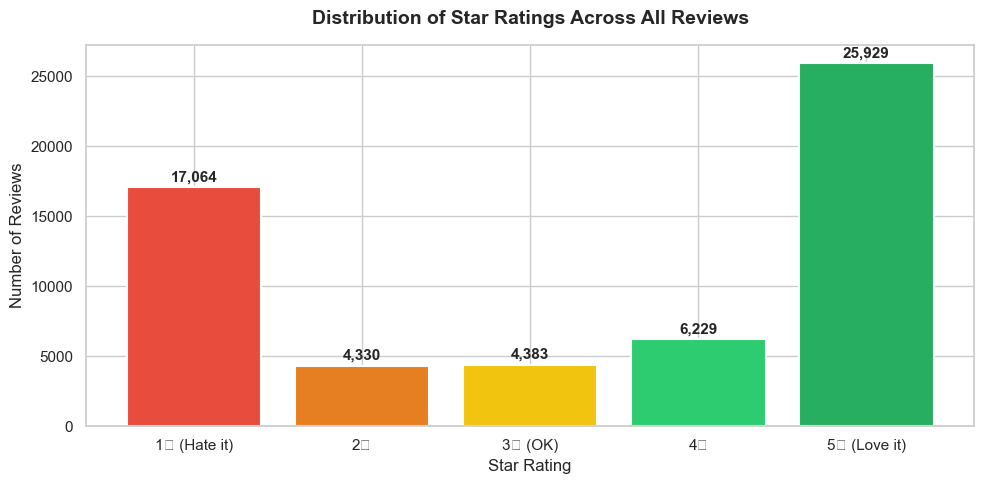

💾 Saved: chart_01_star_distribution.png


In [17]:
# ────────────────────────────────────────────────────────────────────
# CHART 1: Distribution of Star Ratings
# Story: Shows if our dataset is balanced or skewed
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

star_counts = reviews['star_rating'].value_counts().sort_index()
bars = ax.bar(star_counts.index, star_counts.values,
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
              edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, star_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribution of Star Ratings Across All Reviews', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['1★ (Hate it)','2★','3★ (OK)','4★','5★ (Love it)'])
plt.tight_layout()
plt.savefig('chart_01_star_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart_01_star_distribution.png')

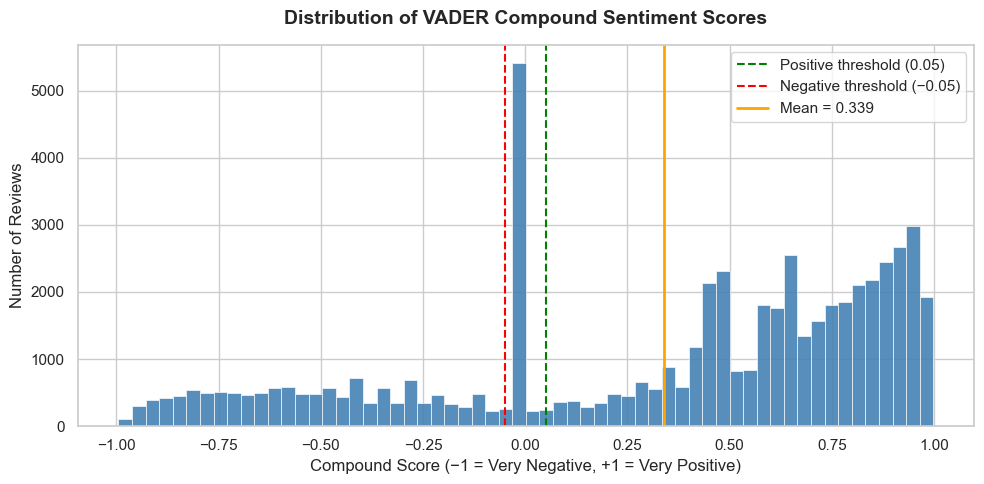

💾 Saved: chart_02_sentiment_distribution.png


In [18]:
# ────────────────────────────────────────────────────────────────────
# CHART 2: VADER Sentiment Score Distribution
# Story: Shows the spread of sentiment in our data
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(reviews['vader_compound'], bins=60, color='steelblue',
        edgecolor='white', linewidth=0.5, alpha=0.9)
ax.axvline(0.05, color='green', linestyle='--', linewidth=1.5, label='Positive threshold (0.05)')
ax.axvline(-0.05, color='red', linestyle='--', linewidth=1.5, label='Negative threshold (−0.05)')
ax.axvline(reviews['vader_compound'].mean(), color='orange', linestyle='-',
           linewidth=2, label=f'Mean = {reviews["vader_compound"].mean():.3f}')

ax.set_title('Distribution of VADER Compound Sentiment Scores', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Compound Score (−1 = Very Negative, +1 = Very Positive)', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart_02_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart_02_sentiment_distribution.png')

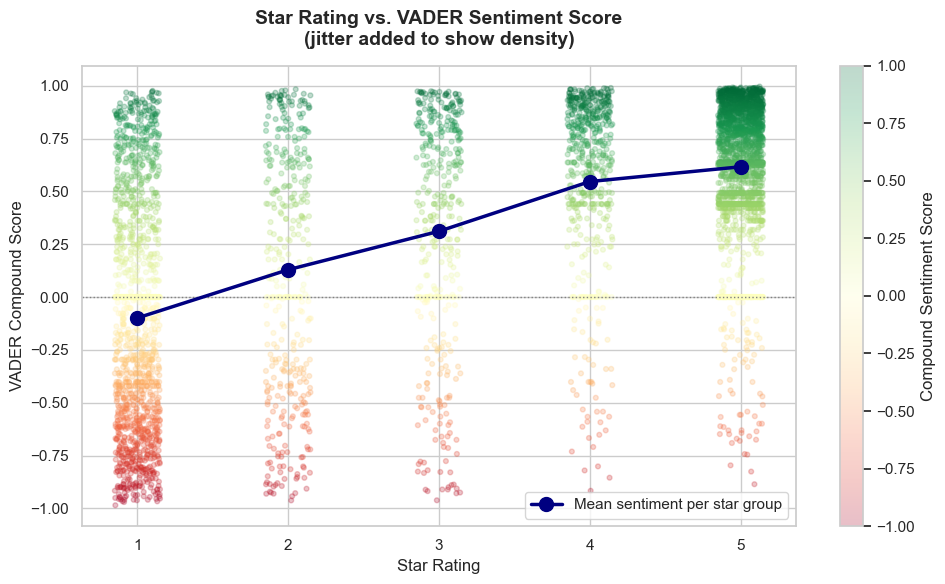

💾 Saved: chart_03_stars_vs_sentiment.png


In [19]:
# ────────────────────────────────────────────────────────────────────
# CHART 3: Star Rating vs Sentiment Score (THE KEY INSIGHT)
# Story: Proves why sentiment analysis adds value beyond raw stars
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Sample 5000 points for speed (plotting 76k would be slow)
sample = reviews.sample(min(5000, len(reviews)), random_state=42)

scatter = ax.scatter(
    sample['star_rating'] + np.random.uniform(-0.15, 0.15, len(sample)),  # add jitter
    sample['vader_compound'],
    alpha=0.25, s=12,
    c=sample['vader_compound'], cmap='RdYlGn', vmin=-1, vmax=1
)

# Add trend line per star group
star_means = reviews.groupby('star_rating')['vader_compound'].mean()
ax.plot(star_means.index, star_means.values, 'o-', color='navy',
        linewidth=2.5, markersize=10, label='Mean sentiment per star group', zorder=5)

plt.colorbar(scatter, ax=ax, label='Compound Sentiment Score')
ax.set_title('Star Rating vs. VADER Sentiment Score\n(jitter added to show density)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('VADER Compound Score', fontsize=12)
ax.set_xticks([1,2,3,4,5])
ax.axhline(0, color='grey', linestyle=':', linewidth=1)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart_03_stars_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart_03_stars_vs_sentiment.png')

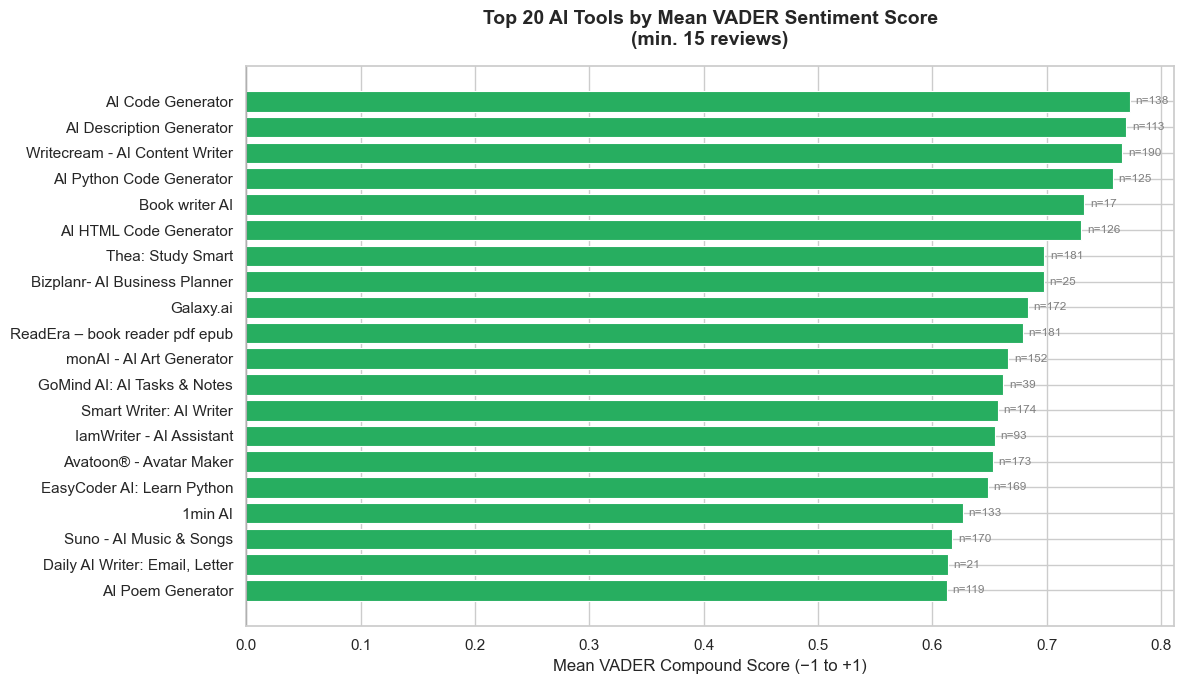

💾 Saved: chart_04_top_tools_sentiment.png


In [20]:
# ────────────────────────────────────────────────────────────────────
# CHART 4: Top 20 Tools by Mean Sentiment Score
# Story: Which tools are genuinely loved based on what users SAY
# ────────────────────────────────────────────────────────────────────
top_tools = (
    tool_sentiment[tool_sentiment['review_count'] >= 15]
    .sort_values('mean_sentiment', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
colours = ['#27ae60' if s >= 0.05 else '#e74c3c' for s in top_tools['mean_sentiment']]

bars = ax.barh(top_tools['app_name'], top_tools['mean_sentiment'],
               color=colours, edgecolor='white', linewidth=0.8)

for bar, count in zip(bars, top_tools['review_count']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={count}', va='center', fontsize=8.5, color='grey')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 AI Tools by Mean VADER Sentiment Score\n(min. 15 reviews)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mean VADER Compound Score (−1 to +1)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart_04_top_tools_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart_04_top_tools_sentiment.png')

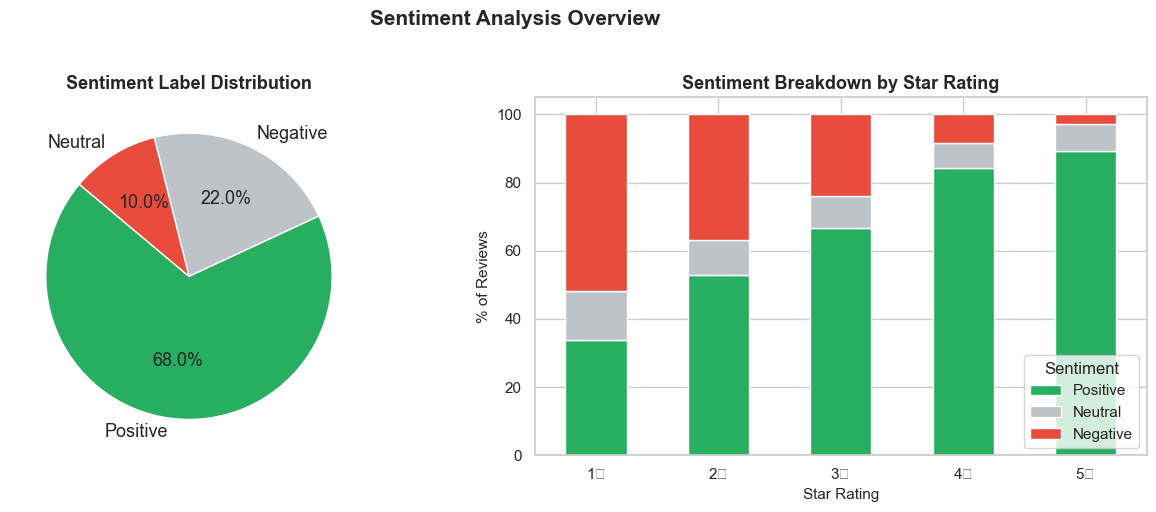

💾 Saved: chart_05_sentiment_overview.png


In [21]:
# ────────────────────────────────────────────────────────────────────
# CHART 5: Sentiment Label Breakdown (Pie chart)
# ────────────────────────────────────────────────────────────────────
label_counts = reviews['sentiment_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
colours_pie = ['#27ae60', '#bdc3c7', '#e74c3c']
axes[0].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            colors=colours_pie, startangle=140,
            textprops={'fontsize': 13})
axes[0].set_title('Sentiment Label Distribution', fontsize=13, fontweight='bold')

# Stacked bar by star rating
cross_tab = pd.crosstab(reviews['star_rating'], reviews['sentiment_label'], normalize='index') * 100
cross_tab[['Positive','Neutral','Negative']].plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#27ae60','#bdc3c7','#e74c3c'],
    edgecolor='white'
)
axes[1].set_title('Sentiment Breakdown by Star Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Star Rating', fontsize=11)
axes[1].set_ylabel('% of Reviews', fontsize=11)
axes[1].set_xticklabels(['1★','2★','3★','4★','5★'], rotation=0)
axes[1].legend(title='Sentiment', loc='lower right')

plt.suptitle('Sentiment Analysis Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_05_sentiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart_05_sentiment_overview.png')

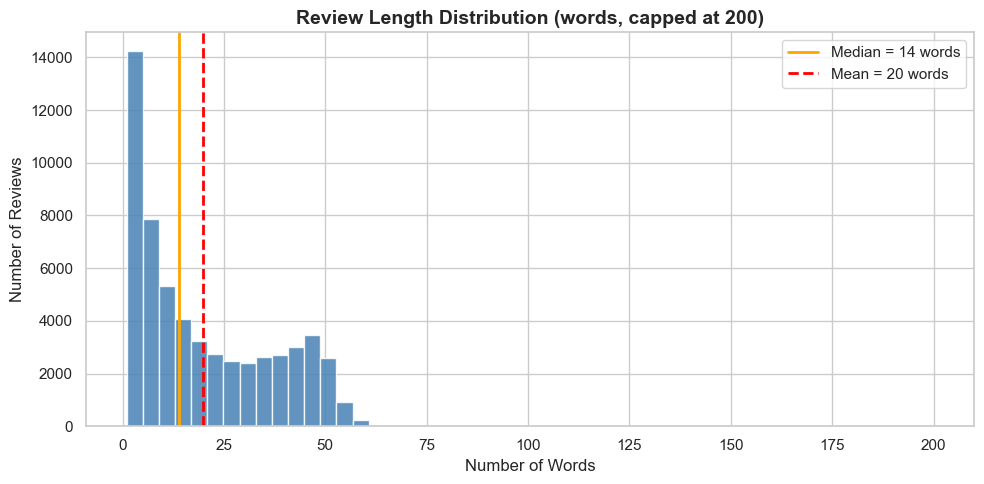

💾 Saved: chart_06_review_length.png


In [22]:
# ────────────────────────────────────────────────────────────────────
# CHART 6: Review Length Distribution
# Story: Understanding review depth — are users writing useful reviews?
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Cap at 500 words for readability (extreme outliers skew the chart)
word_lens = reviews['review_word_len'].clip(upper=200)
ax.hist(word_lens, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(word_lens.median(), color='orange', linewidth=2,
           label=f'Median = {word_lens.median():.0f} words')
ax.axvline(word_lens.mean(), color='red', linewidth=2, linestyle='--',
           label=f'Mean = {word_lens.mean():.0f} words')

ax.set_title('Review Length Distribution (words, capped at 200)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Words', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart_06_review_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart_06_review_length.png')

---
## 💾 Step 9: Save Processed Data

We save three files that future notebooks will use:

| File | What's In It | Used In |
|------|-------------|--------|
| `metadata_clean.csv` | 482 clean AI tool records | Milestone 3 (CF) |
| `reviews_with_sentiment.csv` | All reviews + VADER scores | Milestone 5 (Hybrid) |
| `tool_sentiment_scores.csv` | One sentiment score per tool | Milestone 5 (Hybrid) |

In [23]:
# ── Save cleaned metadata ─────────────────────────────────────────
meta.to_csv(f'{OUTPUT_DIR}metadata_clean.csv', index=False)
print(f'✅ Saved metadata_clean.csv  →  {meta.shape[0]} rows')

# ── Save reviews with sentiment scores ────────────────────────────
reviews.to_csv(f'{OUTPUT_DIR}reviews_with_sentiment.csv', index=False)
print(f'✅ Saved reviews_with_sentiment.csv  →  {len(reviews):,} rows')

# ── Save aggregated tool sentiment scores ─────────────────────────
tool_sentiment.to_csv(f'{OUTPUT_DIR}tool_sentiment_scores.csv', index=False)
print(f'✅ Saved tool_sentiment_scores.csv  →  {len(tool_sentiment)} tools')

print('\n' + '═'*55)
print('🎉  ALL DATA SAVED TO data/processed/')
print('═'*55)

✅ Saved metadata_clean.csv  →  482 rows
✅ Saved reviews_with_sentiment.csv  →  57,935 rows
✅ Saved tool_sentiment_scores.csv  →  482 tools

═══════════════════════════════════════════════════════
🎉  ALL DATA SAVED TO data/processed/
═══════════════════════════════════════════════════════


---
## ✅ Notebook Summary

Congratulations — you've completed Milestones 2 & 4! Here's what you built:

### What We Did:
- ✅ Loaded 482 AI tools + 76,000 reviews from Google Play
- ✅ Cleaned both datasets (missing values, dates, types, noise)
- ✅ Applied full NLP preprocessing pipeline (tokenise → clean → lemmatise)
- ✅ Scored every review with VADER sentiment (−1 to +1)
- ✅ Aggregated sentiment per tool (ready for the hybrid engine)
- ✅ Generated 6 publication-quality charts for your report
- ✅ Saved 3 clean data files ready for Milestone 5

### Key Findings to Write in Your Report:
> - **What % of reviews were positive/negative/neutral?**
> - **What was the mean compound sentiment score?**
> - **Which tools showed the biggest gap between stars and sentiment?**
> - **Why does this gap matter?** (Hint: it proves the value of NLP!)

### Academic Citation for VADER:
> Hutto, C.J. and Gilbert, E.E. (2014) 'VADER: A Parsimonious Rule-based Model for
> Sentiment Analysis of Social Media Text', *Proceedings of the Eighth International
> AAAI Conference on Weblogs and Social Media (ICWSM-14)*.

---

## 🚀 Next Step → Notebook 02: Collaborative Filtering

In the next notebook, we'll use the `metadata_clean.csv` to build the
**User-Item Matrix** and train the collaborative filtering engine.

Open: **`02_collaborative_filtering.ipynb`**